### Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules

/Users/sawyermckenney/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/sawyermckenney/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### Loading the Data:

In [2]:
df = pd.read_parquet('bts_combined.parquet')
df.head()

,FlightDate,Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,Origin,Dest,CRSDepTime,DepDelay,DepDelayMinutes,DepDel15,...,ArrDel15,Cancelled,CancellationCode,Diverted,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2024-04-01,9E,N187GJ,4800.0,AVL,LGA,1140,1.0,1.0,0.0,...,0.0,0.0,NaN,0.0,599.0,NaN,NaN,NaN,NaN,NaN
1,2024-04-02,9E,N297PQ,4800.0,AVL,LGA,1140,27.0,27.0,1.0,...,1.0,0.0,NaN,0.0,599.0,9.0,0.0,2.0,0.0,18.0
2,2024-04-03,9E,N605LR,4800.0,AVL,LGA,1140,4.0,4.0,0.0,...,0.0,0.0,NaN,0.0,599.0,NaN,NaN,NaN,NaN,NaN
3,2024-04-04,9E,N912XJ,4800.0,AVL,LGA,1140,171.0,171.0,1.0,...,1.0,0.0,NaN,0.0,599.0,1.0,0.0,0.0,0.0,170.0
4,2024-04-05,9E,N538CA,4800.0,AVL,LGA,1140,13.0,13.0,0.0,...,0.0,0.0,NaN,0.0,599.0,NaN,NaN,NaN,NaN,NaN


In [3]:
print(df.columns)
print(df.shape)
print(df.dtypes)
df.isna().sum()
print(df.columns.tolist())

Index(['FlightDate', 'Reporting_Airline', 'Tail_Number',
       'Flight_Number_Reporting_Airline', 'Origin', 'Dest', 'CRSDepTime',
       'DepDelay', 'DepDelayMinutes', 'DepDel15', 'ArrDelay',
       'ArrDelayMinutes', 'ArrDel15', 'Cancelled', 'CancellationCode',
       'Diverted', 'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay',
       'SecurityDelay', 'LateAircraftDelay'],
      dtype='str')
(12422421, 22)
FlightDate                         datetime64[us]
Reporting_Airline                        category
Tail_Number                              category
Flight_Number_Reporting_Airline           float64
Origin                                   category
Dest                                     category
CRSDepTime                                  Int64
DepDelay                                  float64
DepDelayMinutes                           float64
DepDel15                                  float64
ArrDelay                                  float64
ArrDelayMinutes                

### Data Cleaning:

In [4]:

df["Tail_Number"] = df["Tail_Number"].cat.add_categories("Unknown").fillna("Unknown")
df["CarrierDelay"] = df["CarrierDelay"].fillna(0)
df["WeatherDelay"] = df["WeatherDelay"].fillna(0)
df["NASDelay"] = df["NASDelay"].fillna(0)
df["SecurityDelay"] = df["SecurityDelay"].fillna(0)
df["LateAircraftDelay"] = df["LateAircraftDelay"].fillna(0)
df["CancellationCode"] = df["CancellationCode"].cat.add_categories("None").fillna("None")
df = df.dropna(subset=["Flight_Number_Reporting_Airline"]).copy() # Drop rows with missing Flight_Number_Reporting_Airline

print(df.isna().sum())

FlightDate                              0
Reporting_Airline                       0
Tail_Number                             0
Flight_Number_Reporting_Airline         0
Origin                                  0
Dest                                    0
CRSDepTime                              0
DepDelay                           163882
DepDelayMinutes                    163882
DepDel15                           163882
ArrDelay                           203742
ArrDelayMinutes                    203742
ArrDel15                           203742
Cancelled                               0
CancellationCode                        0
Diverted                                0
Distance                                0
CarrierDelay                            0
WeatherDelay                            0
NASDelay                                0
SecurityDelay                           0
LateAircraftDelay                       0
dtype: int64


In [5]:
df_flights = df[df["Cancelled"] == 0].copy() # Get's teh cancelled flights 
df_cancelled = df[df["Cancelled"] == 1].copy()
print(df_flights.isna().sum()[df_flights.isna().sum() > 0])
print(df.isna().sum())
print(f"Diverted flights in df_flights: {df_flights['Diverted'].sum():,}")
print(f"ArrDelay nulls in df_flights: {df_flights['ArrDelay'].isna().sum():,}")
df_diverted = df_flights[df_flights["Diverted"] == 1].copy()
df_flights  = df_flights[df_flights["Diverted"] == 0].copy()
remaining_nulls = df_flights.isna().sum()
df_flights = df_flights.dropna(subset=["DepDelay", "ArrDelay"]).copy() 
print("\nRemaining nulls in df_flights:")

ArrDelay           33062
ArrDelayMinutes    33062
ArrDel15           33062
dtype: int64
FlightDate                              0
Reporting_Airline                       0
Tail_Number                             0
Flight_Number_Reporting_Airline         0
Origin                                  0
Dest                                    0
CRSDepTime                              0
DepDelay                           163882
DepDelayMinutes                    163882
DepDel15                           163882
ArrDelay                           203742
ArrDelayMinutes                    203742
ArrDel15                           203742
Cancelled                               0
CancellationCode                        0
Diverted                                0
Distance                                0
CarrierDelay                            0
WeatherDelay                            0
NASDelay                                0
SecurityDelay                           0
LateAircraftDelay             

In [6]:

delay_causes = ["CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"]
df[delay_causes] = df[delay_causes].fillna(0)
df["FlightDate"] = pd.to_datetime(df["FlightDate"])
#df = df.dropna(subset=["DEP_DELAY"])

In [7]:
# Computes route level stats and aggregates by origin and destination
route_df = (
    df_flights.groupby(["Origin", "Dest"])
      .agg(num_flights=("DepDelay", "size"),
          avg_dep_delay=("DepDelay", "mean"),
          pct_delayed=("DepDel15", "mean"),
          avg_carrier_delay=("CarrierDelay", "mean"),
          avg_weather_delay=("WeatherDelay", "mean"),
          avg_nas_delay=("NASDelay", "mean"),
          avg_security_delay=("SecurityDelay", "mean")
      ).reset_index()
)
# convert to %
route_df["pct_delayed"] = route_df["pct_delayed"] * 100

route_df.head()

,Origin,Dest,num_flights,avg_dep_delay,pct_delayed,avg_carrier_delay,avg_weather_delay,avg_nas_delay,avg_security_delay
0,ABE,ATL,759,9.673254,14.756258,6.602108,0.654809,1.901186,0.000000
1,ABE,BNA,143,9.615385,22.377622,2.706294,0.132867,1.195804,1.132867
2,ABE,CLT,1766,15.883918,17.497169,8.118347,1.855040,1.348245,0.008494
3,ABE,DEN,105,3.771429,13.333333,3.838095,0.000000,1.590476,0.000000
4,ABE,FLL,177,11.338983,22.598870,4.581921,0.242938,3.627119,0.000000


In [8]:
# This is a directed graph 
# nx is a library for working with graphs in python
Graph = nx.DiGraph() 
for _, row in route_df.iterrows():
    Graph.add_edge(row["Origin"], row["Dest"], num_flights=row["num_flights"], avg_delay=row["avg_dep_delay"], pct_delayed=row["pct_delayed"])
print("Nodes:", Graph.number_of_nodes())
print("Edges:", Graph.number_of_edges())

Nodes: 356
Edges: 7257


In [9]:
for u, v, d in Graph.edges(data=True): 
    d["weight"] = max(d["avg_delay"], 0) *d["num_flights"] # Computes a weighed delay for each edge 

In [10]:
# Computes page rank with with edge wieghts based on average delay and number of flights
# So as we expected the most important airports are the ones with the most flights and the longest delays
pagerank = nx.pagerank(Graph, weight="weight", max_iter=1000)
pagerank_series = pd.Series(pagerank).sort_values(ascending=False)
pagerank_series.head(15)

DFW    0.062317
ORD    0.047160
DEN    0.046974
ATL    0.036717
CLT    0.029465
PHX    0.023471
LAS    0.021544
MCO    0.020862
LAX    0.019620
BOS    0.019066
EWR    0.019004
DCA    0.018794
SFO    0.018712
LGA    0.017048
SEA    0.016276
dtype: float64

In [11]:
# Computes page rank with edge weight based on the number of flights only 
pagerank_flights = nx.pagerank(Graph, weight="num_flights")
pagerank_flights = pd.Series(pagerank_flights).sort_values(ascending=False)

comparison = pd.DataFrame({
    "delay_rank": pagerank_series,
    "traffic_rank": pagerank_flights
}).sort_values("delay_rank", ascending=False)

comparison.head(15)

,delay_rank,traffic_rank
DFW,0.062317,0.046317
ORD,0.047160,0.042467
DEN,0.046974,0.046733
ATL,0.036717,0.040787
CLT,0.029465,0.026226
PHX,0.023471,0.023403
LAS,0.021544,0.021284
MCO,0.020862,0.017635
LAX,0.019620,0.021584
BOS,0.019066,0.015915


In [12]:
route_df = route_df[route_df["num_flights"] >= 30].copy()
route_df.sort_values("avg_dep_delay", ascending=False).head(10)

,Origin,Dest,num_flights,avg_dep_delay,pct_delayed,avg_carrier_delay,avg_weather_delay,avg_nas_delay,avg_security_delay
4709,MYR,GRR,30,128.733333,46.666667,36.733333,76.700000,0.633333,0.000000
6750,SNA,MIA,106,114.000000,29.245283,96.481132,0.000000,0.915094,0.000000
2791,GUC,DFW,155,84.709677,30.967742,61.812903,3.458065,2.987097,0.212903
4764,OAK,MSO,42,84.166667,45.238095,50.095238,0.000000,22.547619,0.000000
1122,CHS,LCK,40,84.150000,50.000000,31.425000,5.525000,4.575000,0.000000
5872,RNO,JFK,210,83.590476,38.571429,51.433333,0.000000,3.066667,0.000000
3119,IAH,JAN,50,74.660000,44.000000,6.940000,3.160000,2.080000,0.000000
3749,LCK,CHS,39,74.487179,43.589744,59.717949,0.000000,2.846154,0.000000
1162,CKB,SFB,199,73.165829,56.281407,33.633166,2.241206,5.190955,1.386935
5772,RDM,DFW,212,68.995283,46.226415,18.504717,2.066038,3.471698,0.000000


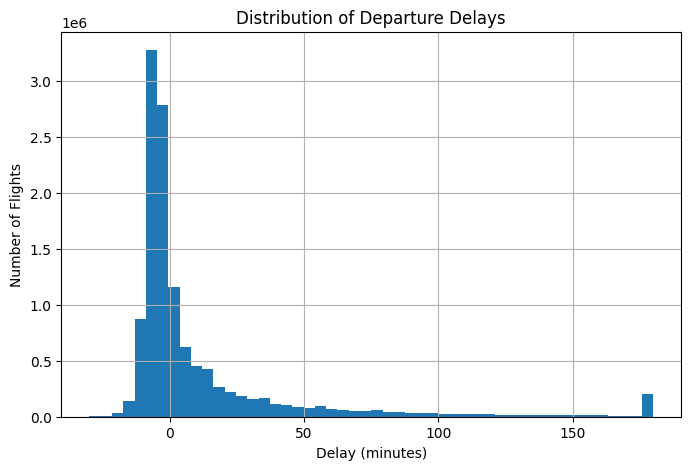

In [13]:
plt.figure(figsize=(8,5))
df["DepDelay"].clip(-30, 180).hist(bins=50)
plt.title("Distribution of Departure Delays")
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of Flights")
plt.show()

This shows that most flight are on time or early

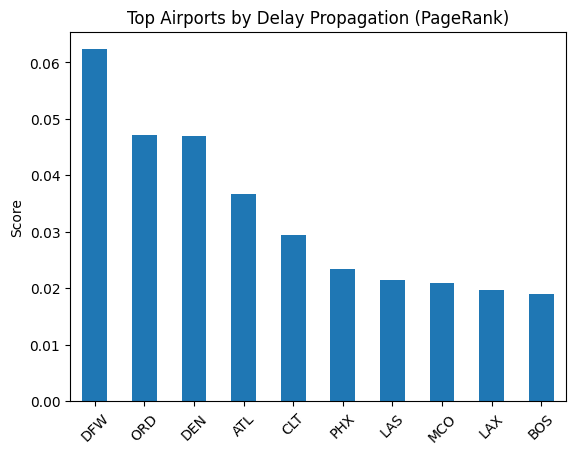

In [14]:
pagerank_series.head(10).plot(kind="bar")
plt.title("Top Airports by Delay Propagation (PageRank)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

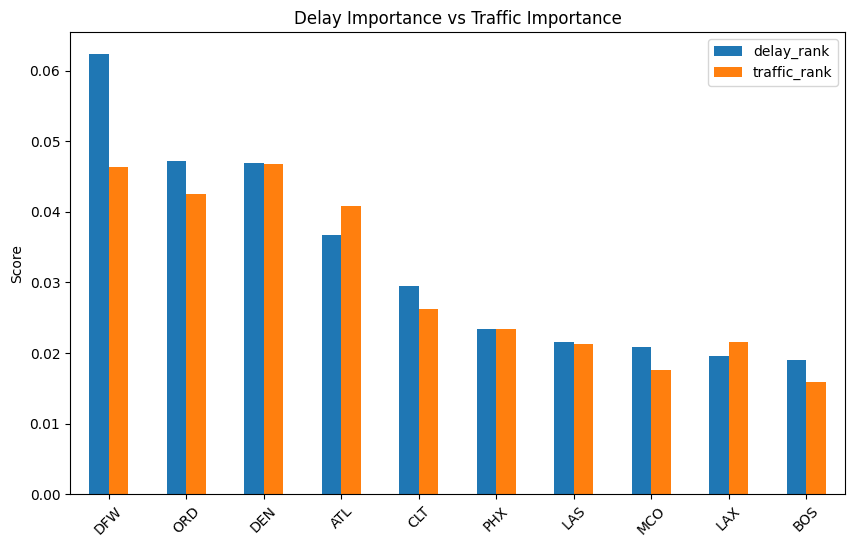

In [15]:
comparison.head(10).plot(kind="bar", figsize=(10,6))
plt.title("Delay Importance vs Traffic Importance")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

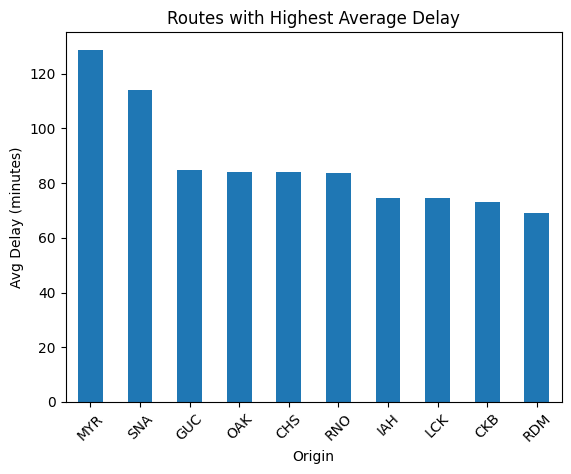

In [16]:
top_routes = route_df[route_df["num_flights"] > 20] \
    .sort_values("avg_dep_delay", ascending=False) \
    .head(10)

top_routes.plot(
    x="Origin",
    y="avg_dep_delay",
    kind="bar",
    legend=False
)

plt.title("Routes with Highest Average Delay")
plt.ylabel("Avg Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

### Network of Top-Ranked Airports by PageRank

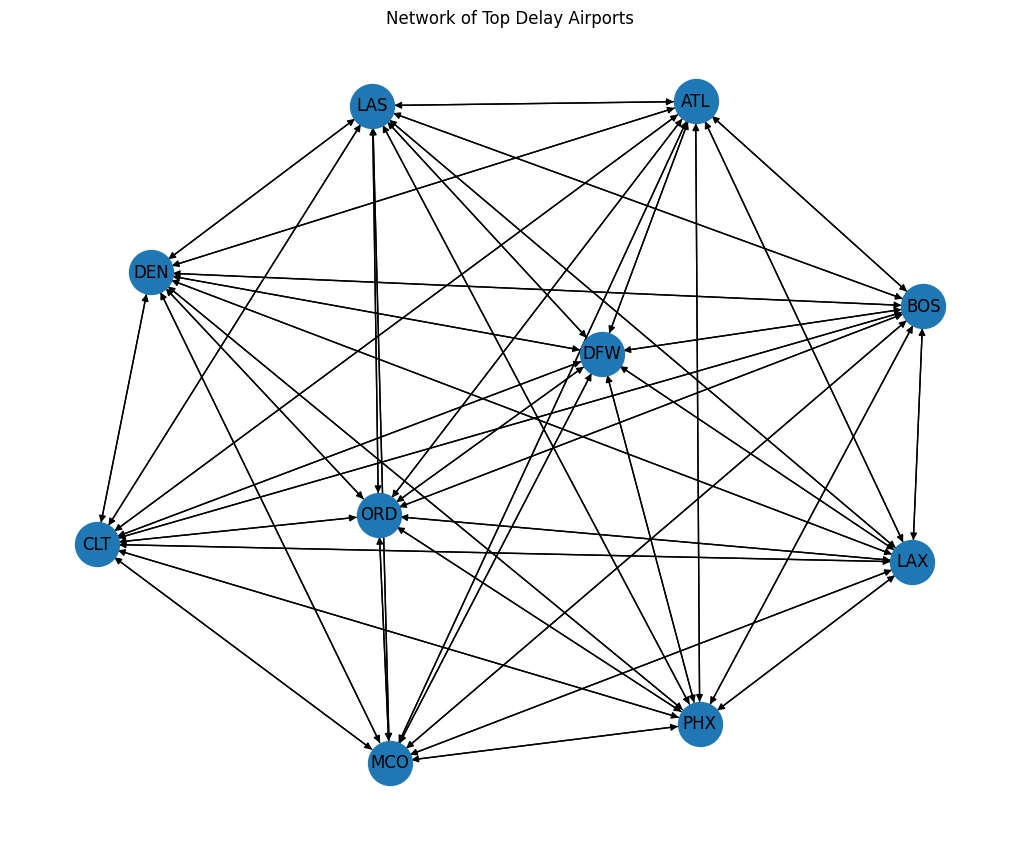

In [17]:
top_airports = set(pagerank_series.head(10).index)

small_df = route_df[
    route_df["Origin"].isin(top_airports) &
    route_df["Dest"].isin(top_airports)
]

G_small = nx.DiGraph() # Create a smaller graph with just the top airports

for _, row in small_df.iterrows():
    G_small.add_edge(row["Origin"], row["Dest"])

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G_small, seed=42)
nx.draw(G_small, pos, with_labels=True, node_size=1000)
plt.title("Network of Top Delay Airports")
plt.show()

In [18]:
# Figure out what is the dominant carrier at each airport 
dominant_carrier = (                                                                                                                                                                        
    df_flights.groupby("Origin")["Reporting_Airline"].agg(lambda s: s.value_counts().idxmax()).rename("dominant_carrier")                                                                                                                                                             
)                                                                                                                                                                                           
                                                                                                                                                                                            
carrier_share = (                                                                                                                                                                           
    df_flights.groupby(["Origin", "Reporting_Airline"]).size().groupby(level=0).apply(lambda s: s.max() / s.sum()).rename("dominant_share")                                                                                                                                                               
)
                                                                                                                                                                                            
airport_carrier = pd.concat([dominant_carrier, carrier_share], axis=1)                                                                                                                      
airport_carrier["dominant_carrier"] = airport_carrier.apply(    
      lambda r: r["dominant_carrier"] if r["dominant_share"] >= 0.40 else "SPLIT",                                                                                                            
      axis=1                                                                                                                                                                                  
  )                                                                                                                                                          
print(airport_carrier.loc[["DFW","ATL","ORD","DEN","CLT","LAX","PHX","LAS","MCO","BOS"]])

       dominant_carrier  dominant_share
Origin                                 
DFW                  AA        0.520402
ATL                  DL        0.717527
ORD               SPLIT        0.304059
DEN               SPLIT        0.330993
CLT                  AA        0.590368
LAX               SPLIT        0.204336
PHX               SPLIT        0.346803
LAS                  WN        0.463318
MCO               SPLIT        0.291937
BOS               SPLIT        0.277036


## Hourly Delay Patterns and Delay Cause Breakdown

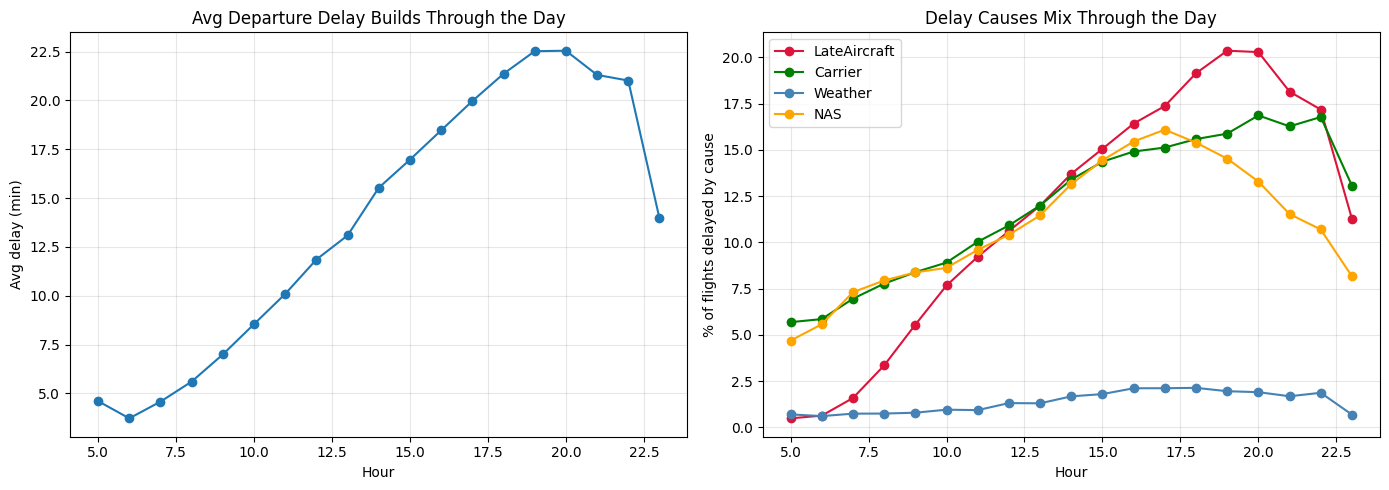

In [19]:
CAUSES = ["LateAircraftDelay", "CarrierDelay", "WeatherDelay", "NASDelay","SecurityDelay"]

df_flights["DepHour"] = df_flights["CRSDepTime"] //100
hourly = (df_flights.query("5 <= DepHour <= 23").groupby("DepHour", observed=True).agg(avg_delay=("DepDelay", "mean"),**{f"pct_{c}": (c, lambda x: x.gt(0).mean()) for c in CAUSES[:4]})) # Average delay and percent of each flight by cause 

ratio = hourly.loc[18:22,"avg_delay"].mean() /hourly.loc[5:9, "avg_delay"].mean() # Ratio of evening delay to morning delay

breakdown = df_flights[CAUSES].sum().sort_values(ascending= False)
                                            
airport_delay = df_flights.groupby("Origin", observed=True)["DepDelay"].apply(lambda s: s.clip(lower=0).sum())                                                                                                                          
top10 = airport_delay.nlargest(10) # Top 10 airports by total delay minutes                                                                                                                                                                                                                                                                                                                                                                   
                                                                                                                                                                                                                                                 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                                                                                                                                                                         
axes[0].plot(hourly.index, hourly["avg_delay"], "o-")                                                                                                                                                     
axes[0].set(title="Avg Departure Delay Builds Through the Day", xlabel= "Hour", ylabel="Avg delay (min)")                                                                                                                                
axes[0].grid(alpha=0.3)                                                                                                                                                                                                                 
                                                                                                                                                                                                                                        
for c, color in zip(CAUSES[:4], ["crimson", "green", "steelblue", "orange"]):
    axes[1].plot(hourly.index, hourly[f"pct_{c}"]*100, "o-", label=c.replace("Delay",""), color=color)                                                                                                                                  
axes[1].set(title="Delay Causes Mix Through the Day", xlabel= "Hour", ylabel="% of flights delayed by cause")                                                                                                                             
axes[1].legend(); axes[1].grid(alpha=0.3)                                                                                                                                                                                               
plt.tight_layout()                                                                                                                                                                                                                      
plt.show()

### Key Delay Metrics 

In [20]:
#Evening vs morning ratio computation                                                                                                                                                                                                          
hourly_avg = df_flights.query("5 <= DepHour <= 23").groupby("DepHour", observed=True)["DepDelay"].mean()                                                                                                                                
ratio = hourly_avg.loc[18:22].mean() / hourly_avg.loc[5:9].mean()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
CAUSES = ["LateAircraftDelay", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay"]                                                                                                                                             
late_aircraft_share = df_flights["LateAircraftDelay"].sum() / df_flights[CAUSES].sum().sum()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
airport_delay = df_flights.groupby("Origin", observed=True)["DepDelay"].apply(lambda s: s.clip(lower=0).sum())                                                                                                                          
top10_share = airport_delay.nlargest(10).sum() / airport_delay.sum()                                                                                                                                                                    
                                                                                                                                                                                                                                        
print(f"Evening < Morning delay ratio: {ratio:.1f}x")                                                                                                                                                                            
print(f"Late aircraft share of all delays: {late_aircraft_share:.1%}")                                                                                                                                                               
print(f"Top 10 airports share of all delays: {top10_share:.1%}")

Evening < Morning delay ratio: 4.3x
Late aircraft share of all delays: 39.8%
Top 10 airports share of all delays: 35.5%


## Daily Feature Engineering groups by day

In [21]:
# Groups flights by days and computes daily features
df_flights["FlightDate"] = pd.to_datetime(df_flights["FlightDate"])      

df_flights["weather_flag"] = (df_flights["WeatherDelay"] > 0).astype(int)
df_flights["late_aircraft_flag"] = (df_flights["LateAircraftDelay"] > 0).astype(int)
df_flights["carrier_flag"] = (df_flights["CarrierDelay"] > 0).astype(int)
df_flights["nas_flag"] = (df_flights["NASDelay"] > 0).astype(int)
                                                                                                                                                                                                                                          
day_features = df_flights.groupby("FlightDate", observed=True).agg(avg_delay=("DepDelay", "mean"),
    total_delay=("DepDelay", "sum"),
    pct_weather_delay=("weather_flag", "mean"),
    pct_late_aircraft=("late_aircraft_flag", "mean"),
    pct_carrier_delay=("carrier_flag", "mean"),
    pct_nas_delay=("nas_flag", "mean"),
    num_flights=("DepDelay", "size"),
)                  
                                                                                                                                                                                                                                        
threshold = day_features["total_delay"].quantile(0.90) # 90 was chose because the data is large is captures the worst 10%                                                                                                                                                                                  
day_features["is_cascade"] = (day_features["total_delay"] >= threshold).astype(int)
day_features["day_of_week"] = day_features.index.dayofweek                                                                                                                                                                              
day_features["is_friday_or_sunday"] = day_features["day_of_week"].isin([4, 6]).astype(int)


## Apriori Baskets

In [22]:
# Make the baskets apriori 
basket_df = pd.DataFrame(index=day_features.index) # Df of the day level features for apriori
#print(df["FlightDate"].value_counts().head())
basket_df["high_weather"] = day_features["pct_weather_delay"] > day_features["pct_weather_delay"].quantile(0.75) 
basket_df["high_late_aircraft"] = day_features["pct_late_aircraft"] > day_features["pct_late_aircraft"].quantile(0.75)
basket_df["high_carrier"] = day_features["pct_carrier_delay"] > day_features["pct_carrier_delay"].quantile(0.75)
basket_df["high_nas"] = day_features["pct_nas_delay"] > day_features["pct_nas_delay"].quantile(0.75)
basket_df["weekend_peak"] = day_features["is_friday_or_sunday"] == 1
basket_df["high_morning_delay"]= day_features["avg_delay"] > day_features["avg_delay"].quantile(0.75)
basket_df["is_cascade"] = day_features["is_cascade"] == 1

In [23]:
frequent = apriori(basket_df, min_support=0.05, use_colnames=True)
rules = association_rules(frequent, metric="lift", min_threshold=1.0)

# Filter rules where the consequent is "is_cascade"/extreme delay days
cascade_rules = rules[rules["consequents"].apply(lambda s: "is_cascade" in s)]
#print(cascade_rules.sort_values("lift", ascending=False).head(20))

In [24]:
cascade_only = cascade_rules[cascade_rules["consequents"] == frozenset({"is_cascade"})]                                                                                              
cascade_only = cascade_only.sort_values("lift", ascending=False).head(10)                                                                                                            
print(cascade_only[["antecedents", "support", "confidence", "lift"]].round(3).to_string(index=False))

                                                                              antecedents  support  confidence  lift
frozenset({high_weather, high_morning_delay, high_nas, high_late_aircraft, high_carrier})    0.081       0.650 6.500
                    frozenset({high_nas, high_weather, high_late_aircraft, high_carrier})    0.081       0.650 6.500
                    frozenset({high_nas, high_weather, high_morning_delay, high_carrier})    0.081       0.642 6.420
                                        frozenset({high_nas, high_weather, high_carrier})    0.081       0.634 6.341
              frozenset({high_nas, high_weather, high_morning_delay, high_late_aircraft})    0.086       0.604 6.044
          frozenset({high_weather, high_morning_delay, high_carrier, high_late_aircraft})    0.083       0.602 6.023
                                  frozenset({high_nas, high_weather, high_late_aircraft})    0.086       0.598 5.978
                              frozenset({high_weather, high_late

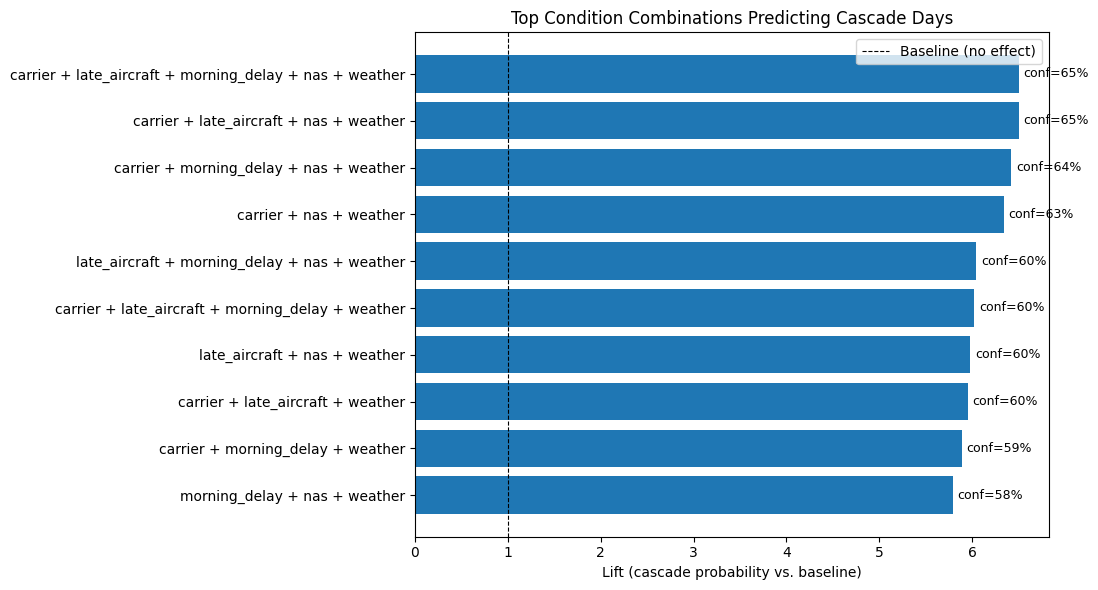

In [25]:
# Take top 10 cascade rules                                                                                                                                                                                                             
top = cascade_only.head(10).copy()                                                                                                                                                                                                      
                                                                                                                                                                                                                                        
# Build readable labels from the frozensets                                                                                                                                                                                             
top["label"] = top["antecedents"].apply(lambda s: " + ".join(sorted([x.replace("high_", "") for x in s])))

plt.figure(figsize=(11, 6))                                                                                                                                                                                                             
plt.barh(top["label"][::-1], top["lift"][::-1]) 
plt.axvline(1.0, color="black", linewidth=0.8, linestyle="--", label="Baseline (no effect)")  # Meaning condition has not effect                                                                                                                                            
plt.xlabel("Lift (cascade probability vs. baseline)")                                                                                                                                                                                   
plt.title("Top Condition Combinations Predicting Cascade Days")
                                                                                                                                                                                                                                        
# Annotate confidence on each bar                                                                                                                                                                                                       
for i, (lift, conf) in enumerate(zip(top["lift"][::-1], top["confidence"][::-1])):                                                                                                                                                      
    plt.text(lift + 0.05, i, f"conf={conf:.0%}", va="center", fontsize=9)                                                                                                                                                               
                                                                
plt.legend()                                                                                                                                                                                                                            
plt.tight_layout()                                              
plt.show()

In [26]:
no_weather = cascade_only[~cascade_only["antecedents"].apply(lambda s: "high_weather" in s)]                                                                                                                                            
print(f"Cascade rules without weather: {len(no_weather)}")                                                                                                                                                                              
if len(no_weather) > 0:                                                                                                                                                                                                                 
    print(no_weather[["antecedents", "support", "confidence", "lift"]].round(3))                                                                                                                                                      
else:                                                                                                                                                                                                                                   
    print("No cascade rules without weather met the min_support threshold") 

Cascade rules without weather: 0
No cascade rules without weather met the min_support threshold
